# Part1.1: Exploratory Data Analysis

In [53]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [54]:
train=pd.read_csv("C:\\Users\\Hzaab\\Desktop\\MLSD project\\data\\raw\\train.csv")
test=pd.read_csv("C:\\Users\\Hzaab\\Desktop\\MLSD project\\data\\raw\\test.csv")

In [55]:
train=train.drop(columns=["Unnamed: 0"])
categorical_cols = ["profile pic", "name==username", "external URL", "private", "fake"]
numeric_columns = [col for col in train.columns if col not in categorical_cols]

## Overall Features

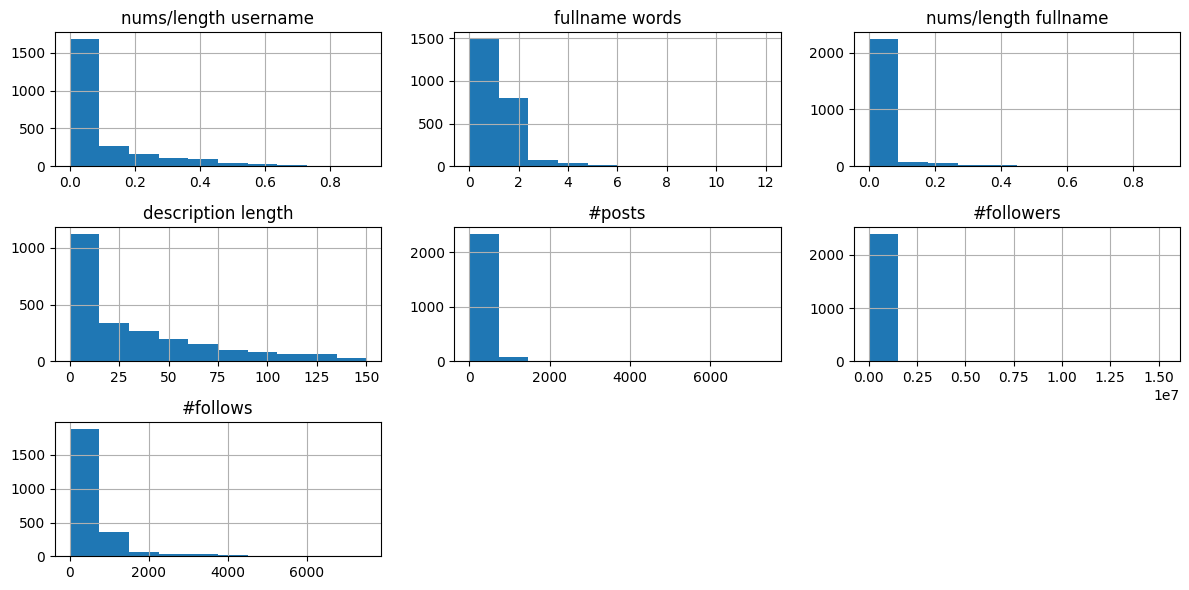

In [56]:
train[numeric_columns].hist(figsize=(12, 6))
plt.tight_layout()
plt.show()

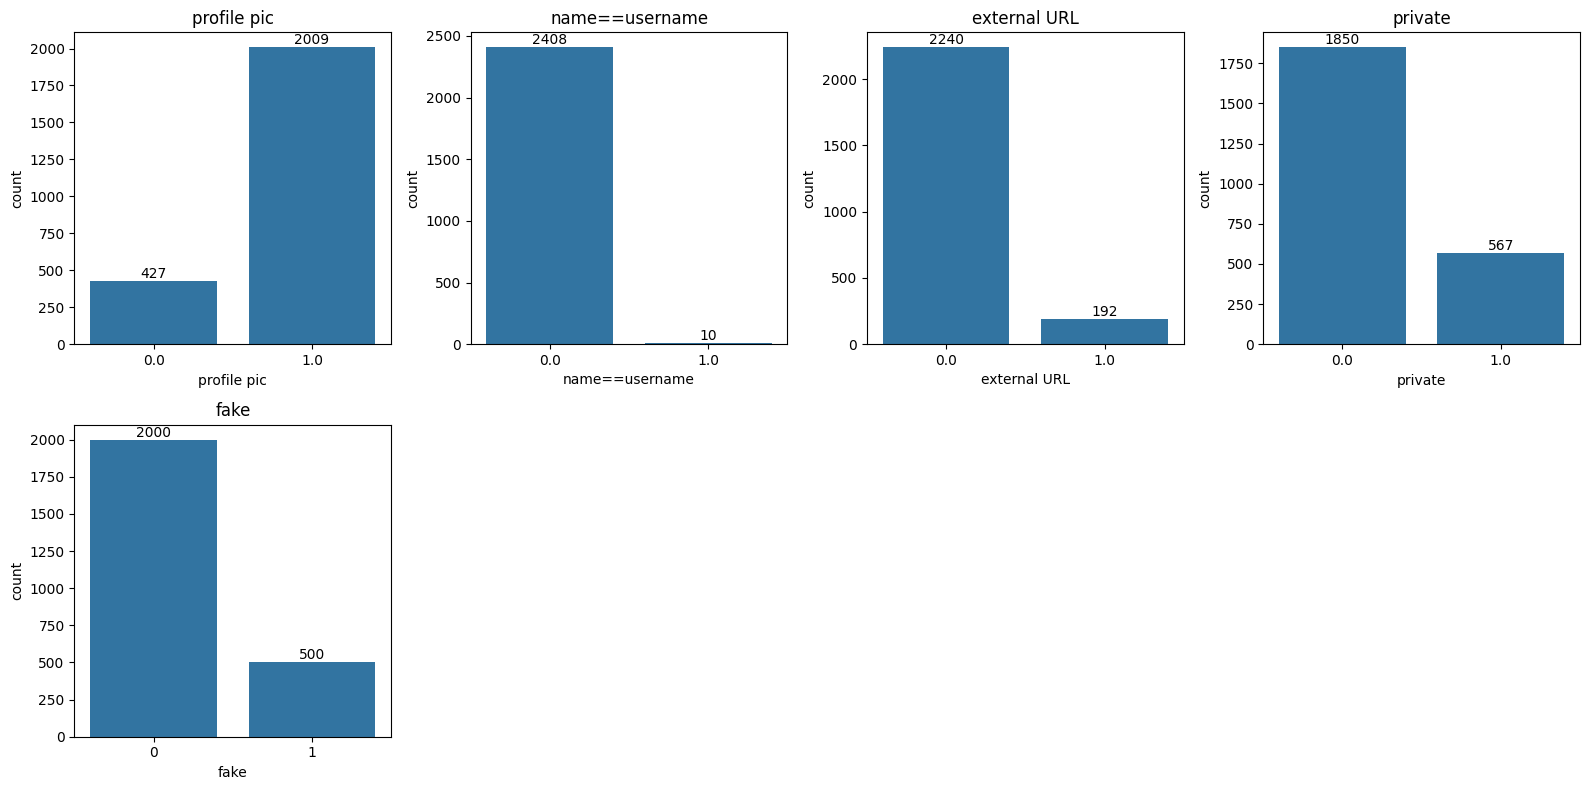

In [57]:

n = len(categorical_cols)
rows = math.ceil(n / 4)
fig, axes = plt.subplots(rows, 4, figsize=(4 * 4, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
    sns.countplot(x=train[col], ax=ax)
    ax.set_title(col)
    ax.set_xticks([0, 1])

    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom"
        )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Skew:
We can see that the numeric features are heavily skewed right, to fix this issue we can take the log transform of the features with large scales, specifically: #follows, #followers, description length, and #posts
Note: we use log1p as it doesnt break when log(0) is inputted, it simply sets it =0

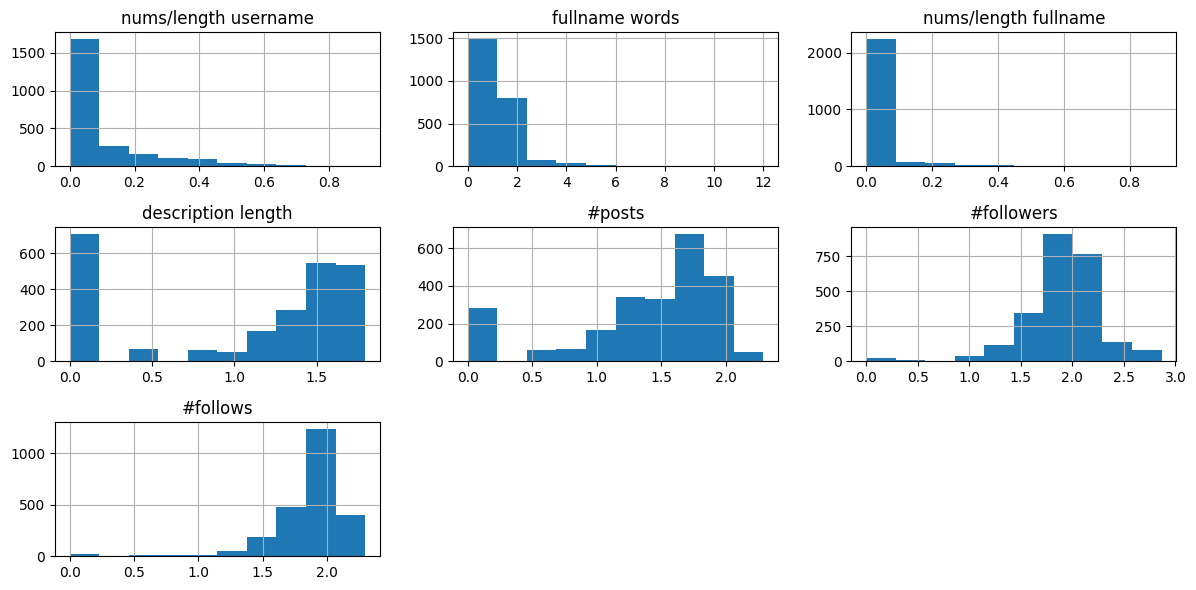

In [59]:
log_cols = ["#follows", "#followers", "description length", "#posts"]
for col in log_cols:
    train[col] = np.log1p(train[col])

train[numeric_columns].hist(figsize=(12, 6))
plt.tight_layout()
plt.show()

## Analyses that raised no issues:

In [60]:
train.head(0)

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake


In [61]:
print("train duplicates:", train.duplicated().sum())

train duplicates: 5


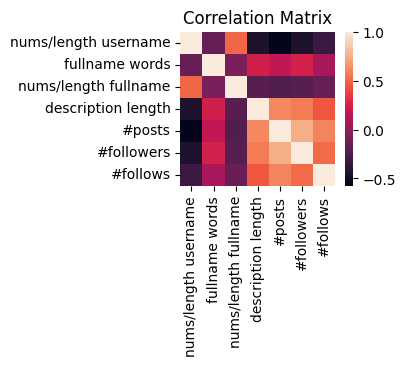

In [72]:
plt.figure(figsize=(2.5, 2))
corr = train[numeric_columns].corr()
sns.heatmap(corr)
plt.title("Correlation Matrix")
plt.show()

In [63]:
outlier_summary = {}

for col in numeric_columns:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lower) | (train[col] > upper)]

    outlier_summary[col] = {
        "count": len(outliers),
        "percent": len(outliers) / len(train) * 100
    }

pd.DataFrame(outlier_summary).T.sort_values("percent", ascending=False)

,count,percent
#posts,281.0,11.24
nums/length fullname,273.0,10.92
nums/length username,253.0,10.12
#followers,172.0,6.88
#follows,130.0,5.20
fullname words,64.0,2.56
description length,0.0,0.00


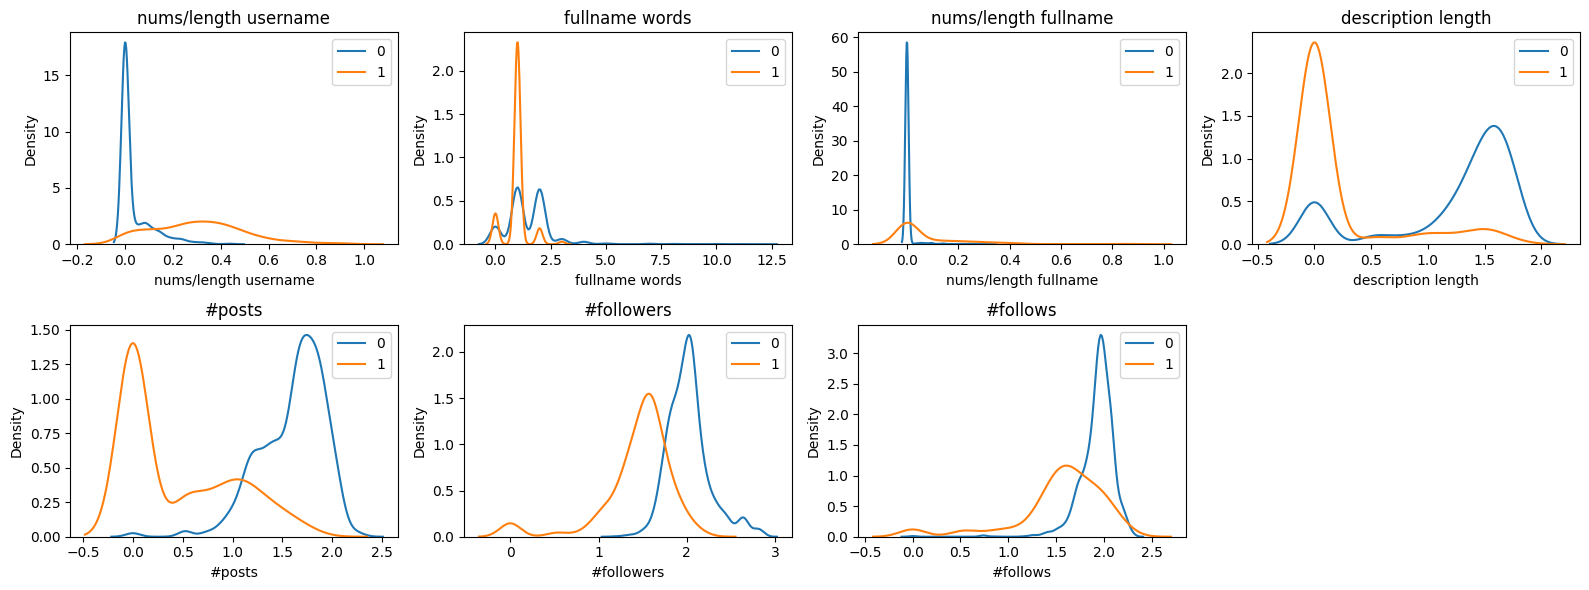

In [93]:
n = len(numeric_columns)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    ax = axes[i]
    
    sns.kdeplot(train[train["fake"] == 0][col], label="0", ax=ax)
    sns.kdeplot(train[train["fake"] == 1][col], label="1", ax=ax)
    
    ax.set_title(col)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Some observations: it seems like there are features that have a clear pattern to the output class, specifically in this order of decreasing info gain: #posts  > #followers > #sollows > desc length, the rest dont really seem to add much info

Future tests  (part ?): we could see what tweaking the weight vs dropping these features entirely does, and compare performance of mlflow

## Analyses that raise issues:

### Features Ranges
Theres a very big difference between the ranges of the features, username length has a range of ~ (0,1) while #followers reaches over 10^7, we also see that the data is heavily right skewed

Solution: Normalization (avoid Min-Max due to sensitivity to outliers, norm is generally more robust)

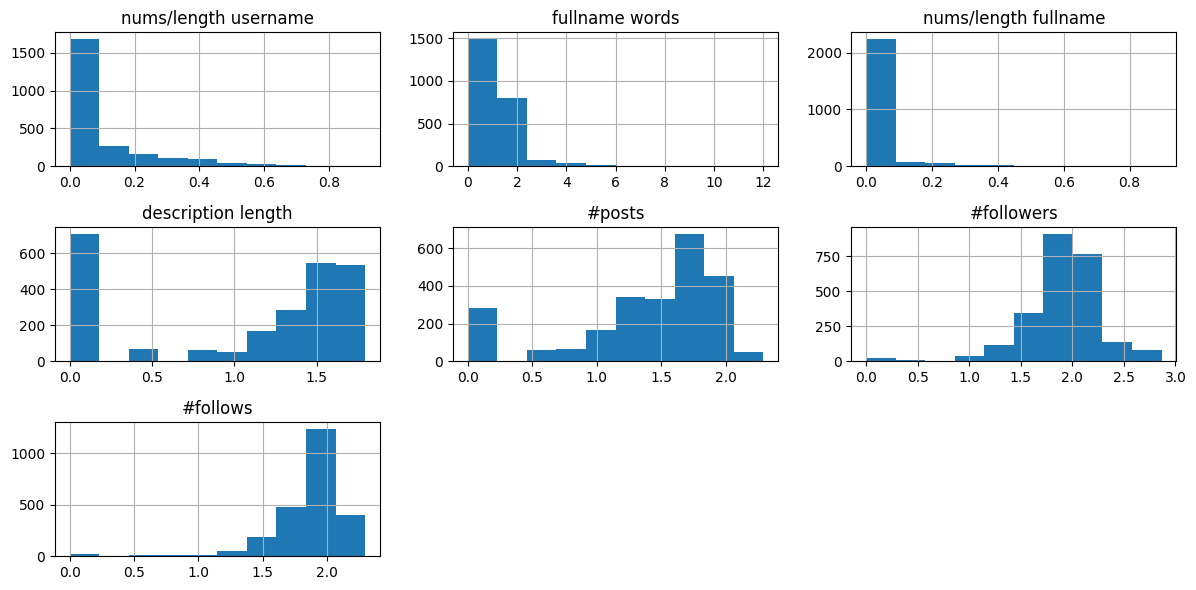

In [64]:
train[numeric_columns].hist(figsize=(12, 6))
plt.tight_layout()
plt.show()

### Null Values
Many features have Null values

Solution: perhaps there's a pattern to the Null values, analyze the Null cell locations first, if none present, use median as all of our data is skewed

Future test (Part_1_2_Null Values): analysis of any patterns in the Null values

train % missing:



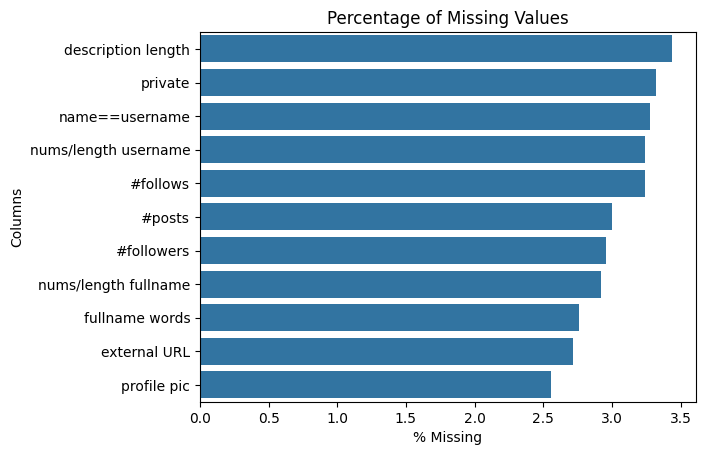

In [7]:
print("train % missing:\n")

nulls = train.isnull().mean() * 100   # 👈 key change
nulls = nulls[nulls > 0]
nulls.sort_values(inplace=True, ascending=False)

plt.figure()
sns.barplot(y=nulls.index, x=nulls.values)

plt.title("Percentage of Missing Values")
plt.ylabel("Columns")
plt.xlabel("% Missing")

plt.show()

## Class Imbalance

we found that there is 4 times as much negative class as there is positive (2k vs 500)

Solution: test many methods including: resampling, smote, undersampling, etc

future tests (Part_1_3_Class imbalance): train a simple model on the current distribution, this will be our baseline, then apply each of the above one at a time, compare model perfomance on MLFlow. Note: Do not use accuracy as the sole metric, it does not reflect performance well during imbalance

fake
0    2000
1     500
Name: count, dtype: int64


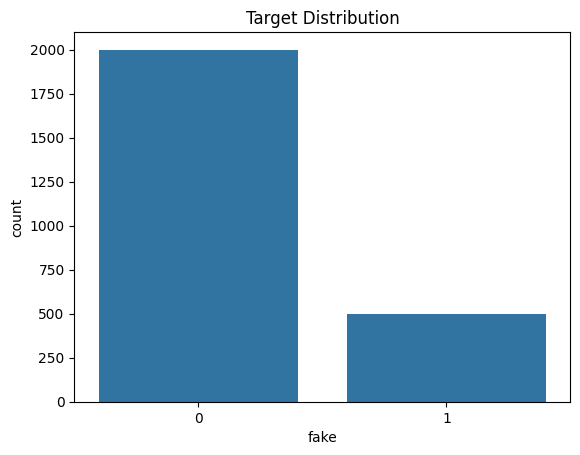

In [110]:
print(train["fake"].value_counts())

plt.figure()
sns.countplot(x=train["fake"])
plt.title("Target Distribution")
plt.show()